In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv('../artifacts/IMDB_Dataset.csv')

In [4]:
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


Data Pre-Processing

In [5]:
data.shape

(50000, 2)

In [6]:
data.duplicated().sum()

np.int64(418)

In [7]:
data.drop_duplicates(inplace=True)

In [8]:
data.isnull().sum()

review       0
sentiment    0
dtype: int64

Text Preprocessing

In [9]:
import re
import string

convert uppercase to lowercase


In [10]:
data["review"] = data["review"].str.lower()

In [11]:
data.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production. <br /><br />the...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically there's a family where a little boy ...,negative
4,"petter mattei's ""love in the time of money"" is...",positive


In [12]:
data["review"] = data["review"].str.replace(r'http?://\S+|www\.\S+', '', regex=True)

remove punctuations


In [13]:
data["review"] = data["review"].str.replace(r'[^\w\s]','', regex=True)

In [14]:
data.tail()


,review,sentiment
49995,i thought this movie did a down right good job...,positive
49996,bad plot bad dialogue bad acting idiotic direc...,negative
49997,i am a catholic taught in parochial elementary...,negative
49998,im going to have to disagree with the previous...,negative
49999,no one expects the star trek movies to be high...,negative


remove numbers

In [15]:
data["review"] = data["review"].str.replace(r'\d+','',regex=True)

remove stop words


In [16]:
import nltk

In [17]:
with open('../static/model/corpora/stopwords/english', 'r') as file:
    sw = file.read().splitlines()

In [18]:
data["review"] = data["review"].apply(lambda x: " ".join(x for x in x.split() if x not in sw))

In [19]:
data.tail()


,review,sentiment
49995,thought movie right good job wasnt creative or...,positive
49996,bad plot bad dialogue bad acting idiotic direc...,negative
49997,catholic taught parochial elementary schools n...,negative
49998,im going disagree previous comment side maltin...,negative
49999,one expects star trek movies high art fans exp...,negative


Stemming

In [20]:
from nltk.stem import PorterStemmer
ps = PorterStemmer()

In [21]:
data["review"] = data["review"].apply(lambda x: " ".join(ps.stem(x) for x in x.split()))

In [22]:
data.head()


,review,sentiment
0,one review mention watch oz episod youll hook ...,positive
1,wonder littl product br br film techniqu unass...,positive
2,thought wonder way spend time hot summer weeke...,positive
3,basic there famili littl boy jake think there ...,negative
4,petter mattei love time money visual stun film...,positive


In [23]:
data["sentiment"] = data["sentiment"].map({"positive": 1, "negative": 0})

In [24]:
data.head()

,review,sentiment
0,one review mention watch oz episod youll hook ...,1
1,wonder littl product br br film techniqu unass...,1
2,thought wonder way spend time hot summer weeke...,1
3,basic there famili littl boy jake think there ...,0
4,petter mattei love time money visual stun film...,1


In [25]:
from collections import Counter
vocab = Counter()

In [26]:
for sentence in data["review"]:
    vocab.update(sentence.split())

In [27]:
len(vocab)

137947

In [28]:
data.shape

(49582, 2)

In [29]:
tokens = [key for key in vocab if vocab[key] > 150]

In [30]:
len(tokens)

4210

In [31]:
def save_vocabulary(lines, filename):
    data = '\n'.join(lines)
    file = open(filename, 'w', encoding="utf-8")
    file.write(data)
    file.close()

save_vocabulary(tokens, '../static/model/vocabulary.txt')

Divide dataset

In [32]:
data

,review,sentiment
0,one review mention watch oz episod youll hook ...,1
1,wonder littl product br br film techniqu unass...,1
2,thought wonder way spend time hot summer weeke...,1
3,basic there famili littl boy jake think there ...,0
4,petter mattei love time money visual stun film...,1
...,...,...
49995,thought movi right good job wasnt creativ orig...,1
49996,bad plot bad dialogu bad act idiot direct anno...,0
49997,cathol taught parochi elementari school nun ta...,0
49998,im go disagre previou comment side maltin one ...,0


In [33]:
x = data['review']
y = data['sentiment']

In [34]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)

In [35]:
x_train.shape

(39665,)

In [36]:
x_test.shape

(9917,)

### Vectorization

In [37]:
def vectorizer(ds, vocabulary):
 vectorized_list = []
 for sentence in ds:
     sentence_list = np.zeros(len(vocabulary))

     for i in range(len(vocabulary)):
         if vocabulary[i] in sentence.split():
             sentence_list[i] = 1

     vectorized_list.append(sentence_list)
 vectorized_list_new = np.array(vectorized_list, dtype=np.float32)

 return vectorized_list_new

In [38]:
vectorized_x_train = vectorizer(x_train, tokens)

In [39]:
vectorized_x_test = vectorizer(x_test, tokens)

In [40]:
y_train.value_counts()

sentiment
1    19999
0    19666
Name: count, dtype: int64

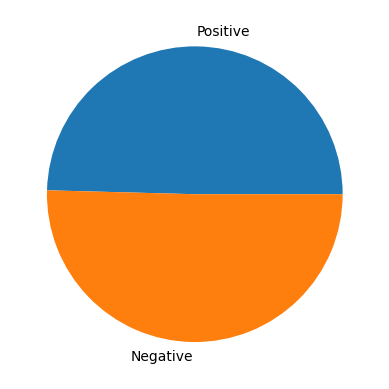

In [41]:
plt.pie(np.array([y_train.value_counts()[0],y_train.value_counts()[1]]),labels=['Positive','Negative'])
plt.show()

## Model Training and Evaluation

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [43]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

def training_scores(y_act, y_pred):
    acc = round(accuracy_score(y_act, y_pred), 3)
    pr = round(precision_score(y_act, y_pred), 3)
    rec = round(recall_score(y_act, y_pred), 3)
    f1 = round(f1_score(y_act, y_pred), 3)
    print(f'Training Scores:\n\tAccuracy = {acc}\n\tPrecision = {pr}\n\tRecall = {rec}\n\tF1-Score = {f1}')


def validation_scores(y_act, y_pred):
    acc = round(accuracy_score(y_act, y_pred), 3)
    pr = round(precision_score(y_act, y_pred), 3)
    rec = round(recall_score(y_act, y_pred), 3)
    f1 = round(f1_score(y_act, y_pred), 3)
    print(f'Training Scores:\n\tAccuracy = {acc}\n\tPrecision = {pr}\n\tRecall = {rec}\n\tF1-Score = {f1}')


### Logistic Regression

In [44]:
lr = LogisticRegression()
lr.fit(vectorized_x_train, y_train)

y_train_pred = lr.predict(vectorized_x_train)
y_test_pred = lr.predict(vectorized_x_test)

training_scores(y_train,y_train_pred)
validation_scores(y_test, y_test_pred)

Training Scores:
	Accuracy = 0.924
	Precision = 0.92
	Recall = 0.93
	F1-Score = 0.925
Training Scores:
	Accuracy = 0.867
	Precision = 0.857
	Recall = 0.875
	F1-Score = 0.866


### Naive Bayes

In [67]:
nb = MultinomialNB()
nb.fit(vectorized_x_train, y_train)

y_train_pred = nb.predict(vectorized_x_train)
y_test_pred = nb.predict(vectorized_x_test)

training_scores(y_train,y_train_pred)
validation_scores(y_test, y_test_pred)

Training Scores:
	Accuracy = 0.852
	Precision = 0.856
	Recall = 0.845
	F1-Score = 0.851
Training Scores:
	Accuracy = 0.843
	Precision = 0.851
	Recall = 0.838
	F1-Score = 0.844


### Decision Tree

In [68]:
dt = DecisionTreeClassifier()
dt.fit(vectorized_x_train, y_train)

y_train_pred = dt.predict(vectorized_x_train)
y_test_pred = dt.predict(vectorized_x_test)

training_scores(y_train,y_train_pred)
validation_scores(y_test, y_test_pred)

Training Scores:
	Accuracy = 1.0
	Precision = 1.0
	Recall = 1.0
	F1-Score = 1.0
Training Scores:
	Accuracy = 0.714
	Precision = 0.721
	Recall = 0.714
	F1-Score = 0.718


### Random Forest

In [69]:
rf = RandomForestClassifier()
rf.fit(vectorized_x_train, y_train)

y_train_pred = rf.predict(vectorized_x_train)
y_test_pred = rf.predict(vectorized_x_test)

training_scores(y_train,y_train_pred)
validation_scores(y_test, y_test_pred)

Training Scores:
	Accuracy = 1.0
	Precision = 1.0
	Recall = 1.0
	F1-Score = 1.0
Training Scores:
	Accuracy = 0.838
	Precision = 0.847
	Recall = 0.831
	F1-Score = 0.839


### Support Vector Classifier

In [ ]:
svm = SVC()
svm.fit(vectorized_x_train, y_train)

y_train_pred = svm.predict(vectorized_x_train)
y_test_pred = svm.predict(vectorized_x_test)

training_scores(y_train,y_train_pred)
validation_scores(y_test, y_test_pred)

In [45]:
import pickle 

with open('../static/model/model.pkl', 'wb') as file:
    pickle.dump(lr,file)